In [389]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [390]:
data = pd.read_csv('data.csv')



In [391]:
df = data
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [392]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [393]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [394]:
from datetime import datetime

current_year = datetime.now().year

df['house_age'] = current_year - df['yr_built']

In [395]:
df['renovated'] = (df['yr_renovated'] > 0).astype(int)

In [396]:
df.drop(['street'], axis=1,inplace=True)

In [397]:
df.drop('country', axis=1,inplace=True)

In [398]:
df.drop('year', axis=1, inplace=True)

In [399]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,month,day,house_age,renovated
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,5,2,71,1
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,5,2,105,0
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,5,2,60,0
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,5,2,63,0
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,5,2,50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,WA 98133,7,9,72,1
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,WA 98007,7,9,43,1
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,WA 98059,7,9,17,0
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,WA 98178,7,10,52,0


In [400]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[us]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  city           4600 non-null   str           
 15  statezip       4600 non-null   s

In [401]:
df.describe(include='object')

C:\Users\Track Computers\AppData\Local\Temp\ipykernel_9592\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,city,statezip
count,4600,4600
unique,44,77
top,Seattle,WA 98103
freq,1573,148


In [402]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip',
       'month', 'day', 'house_age', 'renovated'],
      dtype='str')

In [403]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

corr['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
month            0.041081
condition        0.034915
yr_built         0.021857
day             -0.021544
house_age       -0.021857
renovated       -0.028595
yr_renovated    -0.028774
Name: price, dtype: float64

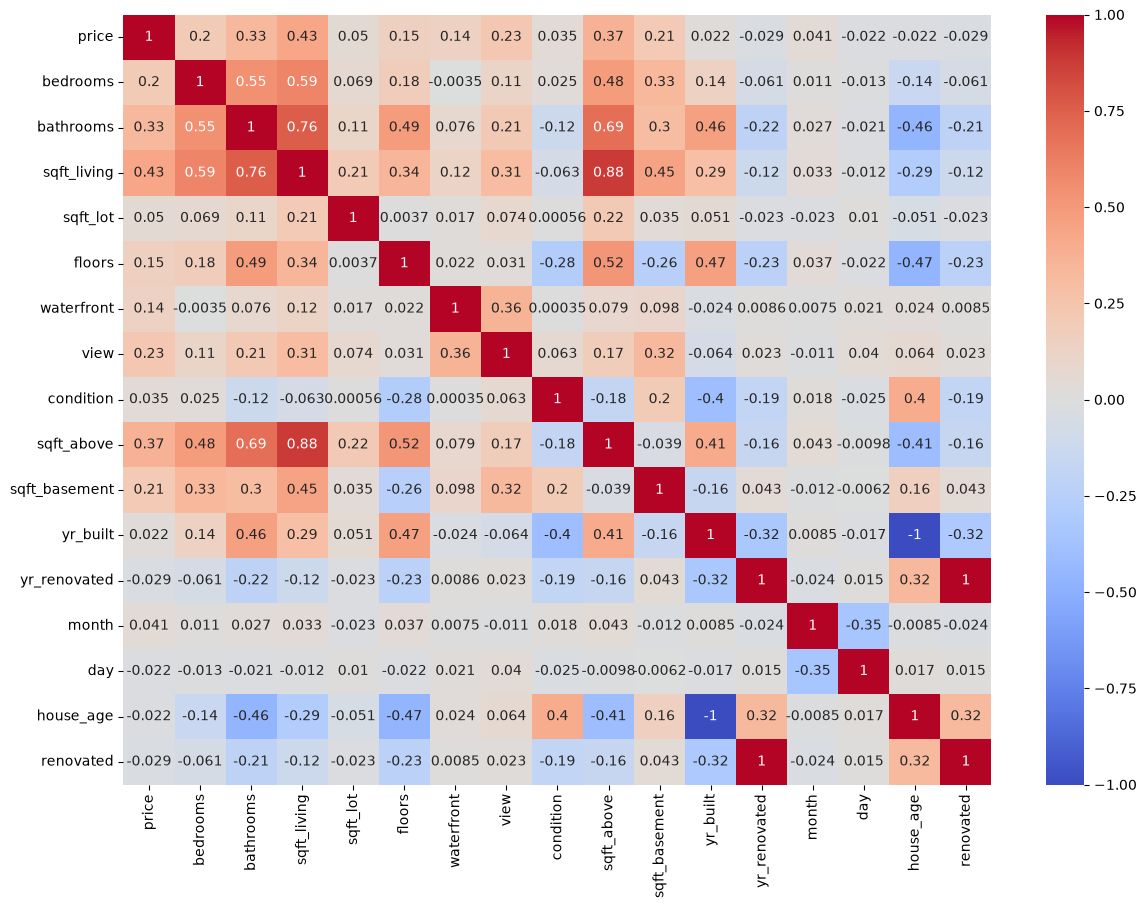

In [404]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(corr,cmap='coolwarm', annot=True)
plt.show()

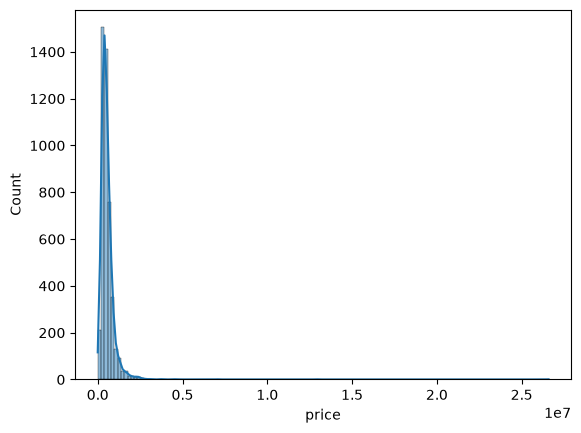

In [405]:
sns.histplot(df['price'], kde=True)
plt.show()

In [406]:
numerical_cols = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living',
    'sqft_lot', 'floors', 'view',
    'sqft_above', 'sqft_basement'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [407]:
print("Before:", df.shape)

numerical_cols = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living',
    'sqft_lot', 'floors', 'view',
    'sqft_above', 'sqft_basement'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After:", df.shape)

Before: (3319, 20)
After: (3161, 20)


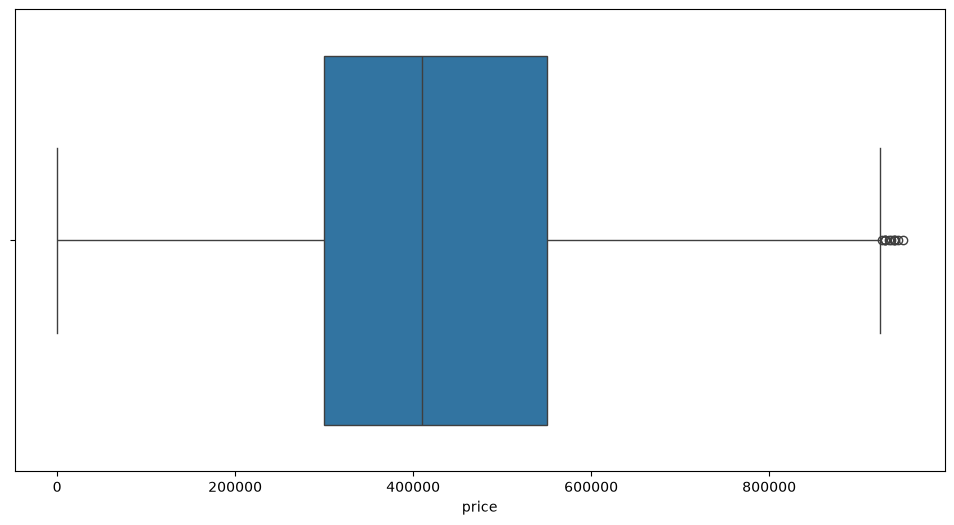

In [408]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df['price'])
plt.show()

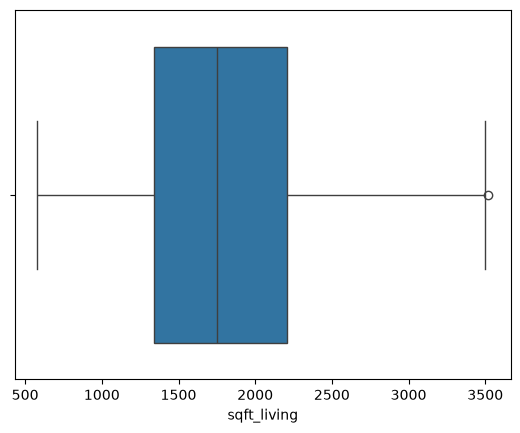

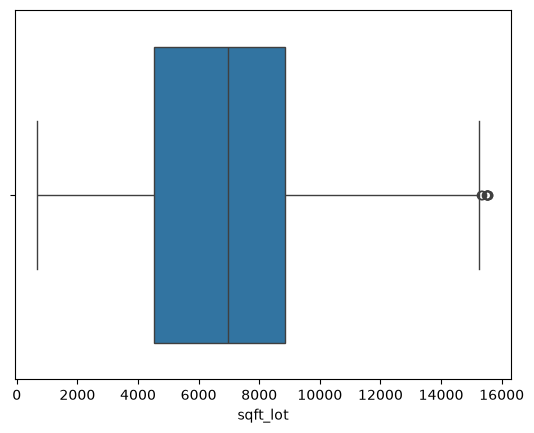

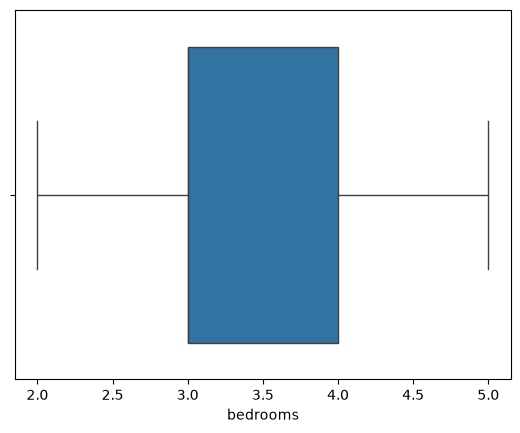

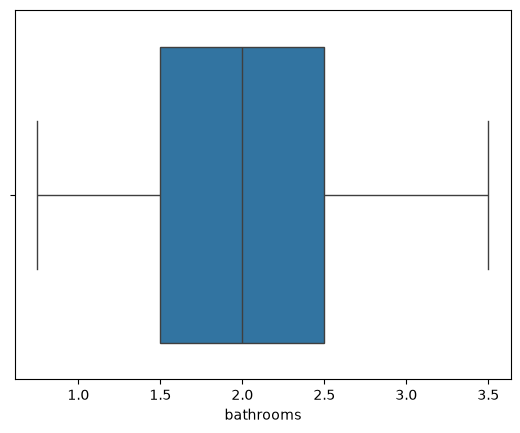

In [409]:
for col in ['sqft_living','sqft_lot','bedrooms','bathrooms']:
    sns.boxplot(x=df[col])
    plt.show()

In [410]:
df = pd.get_dummies(df, columns=['city','statezip'], drop_first=True)

In [411]:
df.drop('date', axis=1, inplace=True,)

In [412]:
df = df.astype(int)

In [413]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000,3,1,1340,7912,1,0,0,3,1340,...,0,0,0,0,0,0,0,0,0,0
2,342000,3,2,1930,11947,1,0,0,4,1930,...,0,0,0,0,0,0,0,0,0,0
3,420000,3,2,2000,8030,1,0,0,4,1000,...,0,0,0,0,0,0,0,0,0,0
4,550000,4,2,1940,10500,1,0,0,4,1140,...,0,0,0,0,0,0,0,0,0,0
5,490000,2,1,880,6380,1,0,0,3,880,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308166,3,1,1510,6360,1,0,0,4,1510,...,0,0,0,0,0,0,0,0,0,0
4596,534333,3,2,1460,7573,2,0,0,3,1460,...,0,0,0,0,0,0,0,0,0,0
4597,416904,3,2,3010,7014,2,0,0,3,3010,...,0,0,0,0,0,0,0,0,0,0
4598,203400,4,2,2090,6630,1,0,0,3,1070,...,0,0,0,0,1,0,0,0,0,0


In [414]:
from sklearn.model_selection  import train_test_split

In [415]:
X = df.drop('price' , axis =1)
y = df['price']

In [416]:
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42)

In [417]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [418]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

results = {}

for name, model in models.items():

    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results[name] = [r2, mae, rmse]

for model, score in results.items():
    print(model)
    print("R2 :", score[0])
    print("MAE:", score[1])
    print("RMSE:", score[2])
    print("-"*40)

Linear Regression
R2 : 0.7550975011512202
MAE: 59962.33730651419
RMSE: 88215.05323545098
----------------------------------------
Random Forest
R2 : 0.6669465505498565
MAE: 69033.28477093206
RMSE: 102873.3921081582
----------------------------------------
Gradient Boosting
R2 : 0.66084821708533
MAE: 72333.05597195544
RMSE: 103810.94501948978
----------------------------------------
Extra Trees
R2 : 0.7125386909244638
MAE: 63117.064375987364
RMSE: 95573.12615301038
----------------------------------------
XGBoost
R2 : 0.7181805372238159
MAE: 65083.5
RMSE: 94630.59564432637
----------------------------------------


In [419]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# R² Score
r2 = r2_score(y_test, y_pred)

# Adjusted R² Score
n = X_test.shape[0]      # Number of test samples
p = X_test.shape[1]      # Number of independent features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Linear Regression Results")
print("-" * 35)
print(f"R² Score         : {r2:.4f}")
print(f"Adjusted R² Score: {adjusted_r2:.4f}")

Linear Regression Results
-----------------------------------
R² Score         : 0.7551
Adjusted R² Score: 0.6904


In [420]:
import joblib

joblib.dump(lr, "linear_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [422]:
print(X.columns.tolist())

['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'month', 'day', 'house_age', 'renovated', 'city_Auburn', 'city_Beaux Arts Village', 'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 'city_Burien', 'city_Carnation', 'city_Covington', 'city_Des Moines', 'city_Duvall', 'city_Enumclaw', 'city_Fall City', 'city_Federal Way', 'city_Inglewood-Finn Hill', 'city_Issaquah', 'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park', 'city_Maple Valley', 'city_Mercer Island', 'city_Milton', 'city_Newcastle', 'city_Normandy Park', 'city_North Bend', 'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond', 'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle', 'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie', 'city_Snoqualmie Pass', 'city_Tukwila', 'city_Vashon', 'city_Woodinville', 'city_Yarrow Point', 'statezip_WA 98002', 'statezip_WA 98003', 'statez

In [423]:
df.sample(5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
3461,580000,4,1,1720,6975,1,0,0,3,1420,...,0,0,0,0,0,0,0,0,0,0
4318,342500,2,1,1210,7507,1,0,0,3,1210,...,0,0,0,0,0,0,0,0,0,0
2684,449950,4,2,2470,3811,2,0,0,3,2470,...,0,0,0,0,0,0,0,0,0,0
1439,840000,4,2,3040,2800,2,0,0,3,2100,...,0,0,0,0,0,0,0,0,0,0
1748,471000,4,2,3030,9687,2,0,0,3,2020,...,0,0,0,0,0,0,0,0,0,0
